# Model Behavior Analysis: Progressive Sender Removal
## Tracking all 6 models + ensemble as senders are removed one-by-one from 23 down to 2

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from scipy.sparse import hstack, csr_matrix
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [35]:
# Load and prepare data
df_raw_cleaned = pd.read_csv("whatsapp_chat_cleaned.csv")

# Apply same filters as test.ipynb
sender_counts = df_raw_cleaned['sender'].value_counts()
senders_over_400 = sender_counts[sender_counts > 400].index
df_filtered = df_raw_cleaned[df_raw_cleaned['sender'].isin(senders_over_400)].copy()
df_filtered = df_filtered[(df_filtered['word_count'] > 5) & (df_filtered['word_count'] <= 100)].copy()

print(f"Loaded {len(df_filtered)} messages from {df_filtered['sender'].nunique()} senders")
print(f"\nSender distribution:")
print(df_filtered['sender'].value_counts())

Loaded 9918 messages from 23 senders

Sender distribution:
sender
Hamza Ihsan                1259
Nofal Zia (BU)             1208
Laiba BU                    672
Chomu Hashim Nazir (BU)     561
Humayun Tariq BU            523
Mubarak Andrabi BU          508
Wajahat BU                  477
Awais Ibrahim BU PGC        459
Fasih (BU)                  419
Hashir BU                   411
Rafay Ali (BU)              401
Mazen مازین (BU)            349
Saad Front Seater BU        298
Abdul Rahim BU              296
+92 319 5512952             272
Momin BU                    266
Zulfiqar Ali BU             260
Sidra BU                    258
Usama (BU)                  248
Shaheer Hassan BU           236
Muzammil BU                 212
Ahmed BU | Annoying Guy     201
Hammad Essay Wala BU        124
Name: count, dtype: int64


In [36]:
# Create stratified train/test split (fixed for all iterations)
df_balanced = df_filtered.copy()
df_balanced['custom_split'] = 'train'

np.random.seed(42)
for sender in df_balanced['sender'].unique():
    sender_mask = df_balanced['sender'] == sender
    sender_indices = df_balanced[sender_mask].index
    train_idx, test_idx = train_test_split(sender_indices, test_size=0.2, random_state=42)
    df_balanced.loc[test_idx, 'custom_split'] = 'test'

test_data = df_balanced[df_balanced['custom_split'] == 'test'].copy()

print(f"Test set: {len(test_data)} messages (fixed for all iterations)")
print(f"Test senders: {test_data['sender'].nunique()} senders")

Test set: 1995 messages (fixed for all iterations)
Test senders: 23 senders


In [37]:
# Utility functions for model training and evaluation
def train_and_evaluate_models(train_data, test_data, iteration_num):
    # \"\"\"Train all 6 models and ensemble on given training set, evaluate on test set\"\"\"
    
    results = {'num_senders': train_data['sender'].nunique(), 'train_size': len(train_data)}
    
    # ===== MODEL 1: BOW + Naive Bayes =====
    bow_vec = CountVectorizer(analyzer='word', ngram_range=(1, 2), max_features=10000, min_df=2)
    X_train_bow = bow_vec.fit_transform(train_data['message_clean_lower'])
    X_test_bow = bow_vec.transform(test_data['message_clean_lower'])
    bow_model = MultinomialNB(alpha=0.5)
    bow_model.fit(X_train_bow, train_data['sender'])
    bow_pred = bow_model.predict(X_test_bow)
    bow_proba = bow_model.predict_proba(X_test_bow)
    results['BOW+NB'] = accuracy_score(test_data['sender'], bow_pred)
    
    # ===== MODEL 2: TF-IDF Word + NB =====
    tfidf_vec = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), max_features=10000, min_df=2)
    X_train_tfidf = tfidf_vec.fit_transform(train_data['message_clean_lower'])
    X_test_tfidf = tfidf_vec.transform(test_data['message_clean_lower'])
    tfidf_model = MultinomialNB(alpha=0.5)
    tfidf_model.fit(X_train_tfidf, train_data['sender'])
    tfidf_pred = tfidf_model.predict(X_test_tfidf)
    tfidf_proba = tfidf_model.predict_proba(X_test_tfidf)
    results['TF-IDF+NB'] = accuracy_score(test_data['sender'], tfidf_pred)
    
    # ===== MODEL 3: Char n-grams + TF-IDF + NB =====
    char_vec = TfidfVectorizer(analyzer='char', ngram_range=(3, 5), max_features=10000, min_df=2)
    X_train_char = char_vec.fit_transform(train_data['message_clean_lower'])
    X_test_char = char_vec.transform(test_data['message_clean_lower'])
    char_model = MultinomialNB(alpha=0.5)
    char_model.fit(X_train_char, train_data['sender'])
    char_pred = char_model.predict(X_test_char)
    char_proba = char_model.predict_proba(X_test_char)
    results['Char+NB'] = accuracy_score(test_data['sender'], char_pred)
    
    # ===== MODEL 4: Char n-grams + LogReg =====
    char_lr_model = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced')
    char_lr_model.fit(X_train_char, train_data['sender'])
    char_lr_pred = char_lr_model.predict(X_test_char)
    char_lr_proba = char_lr_model.predict_proba(X_test_char)
    results['Char+LogReg'] = accuracy_score(test_data['sender'], char_lr_pred)
    
    # ===== MODEL 5: BOW + Handcrafted Features + NB =====
    handcrafted_cols = ['char_count', 'word_count', 'avg_word_length', 'uppercase_ratio', 
                        'punctuation_count', 'digit_count', 'emoji_count', 'has_emoji', 
                        'question_mark_count', 'exclamation_count', 'url_count', 'language_mix_ratio']
    available_cols = [col for col in handcrafted_cols if col in train_data.columns]
    
    X_train_hand_text = bow_vec.fit_transform(train_data['message_clean_lower'])
    X_test_hand_text = bow_vec.transform(test_data['message_clean_lower'])
    scaler = MinMaxScaler()
    X_train_hand_feat = scaler.fit_transform(train_data[available_cols].fillna(0))
    X_test_hand_feat = scaler.transform(test_data[available_cols].fillna(0))
    X_train_hand = hstack([X_train_hand_text, csr_matrix(X_train_hand_feat)])
    X_test_hand = hstack([X_test_hand_text, csr_matrix(X_test_hand_feat)])
    
    hand_model = MultinomialNB(alpha=0.5)
    hand_model.fit(X_train_hand, train_data['sender'])
    hand_pred = hand_model.predict(X_test_hand)
    hand_proba = hand_model.predict_proba(X_test_hand)
    results['BOW+Hand+NB'] = accuracy_score(test_data['sender'], hand_pred)
    
    # ===== ENSEMBLE: Soft Voting of all 5 models =====
    ensemble_classes = bow_model.classes_
    models_probas = [
        (bow_model, bow_proba),
        (tfidf_model, tfidf_proba),
        (char_model, char_proba),
        (char_lr_model, char_lr_proba),
        (hand_model, hand_proba)
    ]
    
    aligned_probas = []
    for model, proba in models_probas:
        if not np.array_equal(model.classes_, ensemble_classes):
            class_to_idx = {label: idx for idx, label in enumerate(model.classes_)}
            reordered = np.zeros((proba.shape[0], len(ensemble_classes)))
            for target_idx, label in enumerate(ensemble_classes):
                reordered[:, target_idx] = proba[:, class_to_idx[label]]
            proba = reordered
        aligned_probas.append(proba)
    
    ensemble_proba = np.mean(aligned_probas, axis=0)
    ensemble_pred = ensemble_classes[np.argmax(ensemble_proba, axis=1)]
    results['Ensemble'] = accuracy_score(test_data['sender'], ensemble_pred)
    
    return results

print("✓ Utility functions defined")

✓ Utility functions defined


In [48]:
# Main iterative loop: Progressively increase minimum message threshold until 2 senders remain
print("\n" + "="*60)
print("STARTING ITERATIVE ANALYSIS")
print("="*60)

df_base = df_balanced[df_balanced['custom_split'] == 'train'].copy()
initial_senders = sorted(df_base['sender'].unique())
results_history = []
iteration = 0

# Start with current threshold and gradually increase
min_thresholds = []
current_threshold = int(df_base['sender'].value_counts().min()) - 1

print(f"Starting with {len(initial_senders)} senders")
print(f"Initial message counts: min={df_base['sender'].value_counts().min()}, max={df_base['sender'].value_counts().max()}")
print(f"Increasing min message threshold until 2 senders remain...\n")

while True:
    # Filter by current threshold
    sender_counts_current = df_base['sender'].value_counts()
    senders_above_threshold = sender_counts_current[sender_counts_current > current_threshold].index
    train_data = df_base[df_base['sender'].isin(senders_above_threshold)].copy()
    active_test_data = test_data[test_data['sender'].isin(senders_above_threshold)].copy()
    
    # Stop if we have 2 or fewer senders
    if len(train_data['sender'].unique()) <= 2:
        break
    
    # Skip iterations that would have no matching test rows
    if len(active_test_data) == 0:
        current_threshold += max(1, (current_threshold // 5))
        iteration += 1
        continue
    
    # Evaluate current state on only the active senders
    iter_results = train_and_evaluate_models(train_data, active_test_data, iteration)
    iter_results['min_threshold'] = current_threshold
    iter_results['test_size'] = len(active_test_data)
    iter_results['test_senders'] = active_test_data['sender'].nunique()
    results_history.append(iter_results)
    
    if iteration % 2 == 0:  # Print every 2 iterations
        print(f"[Iter {iteration}] Min Messages: {current_threshold:4d}, Senders: {iter_results['num_senders']:2d}, "
              f"Train Size: {iter_results['train_size']:5d}, Test Size: {iter_results['test_size']:5d}, "
              f"Ensemble Acc: {iter_results['Ensemble']:.4f}")
    
    # Increase threshold for next iteration
    # Find the next unique message count to jump to
    remaining_counts = sender_counts_current[sender_counts_current > current_threshold].sort_values()
    if len(remaining_counts) > 1:
        # Jump to the next level down
        next_threshold = int(remaining_counts.iloc[0])
        current_threshold = next_threshold
    else:
        # Last sender(s), increase by fixed amount
        current_threshold += max(1, (current_threshold // 5))
    
    iteration += 1

# Final evaluation with 2 or fewer senders
sender_counts_final = df_base['sender'].value_counts()
senders_final = sender_counts_final[sender_counts_final > current_threshold].index
train_data_final = df_base[df_base['sender'].isin(senders_final)].copy()
active_test_data_final = test_data[test_data['sender'].isin(senders_final)].copy()

if len(train_data_final['sender'].unique()) >= 2 and len(active_test_data_final) > 0:
    final_results = train_and_evaluate_models(train_data_final, active_test_data_final, iteration)
    final_results['min_threshold'] = current_threshold
    final_results['test_size'] = len(active_test_data_final)
    final_results['test_senders'] = active_test_data_final['sender'].nunique()
    results_history.append(final_results)
    print(f"\n[Final] Min Messages: {current_threshold:4d}, Senders: {final_results['num_senders']:2d}, "
          f"Train Size: {final_results['train_size']:5d}, Test Size: {final_results['test_size']:5d}, "
          f"Ensemble Acc: {final_results['Ensemble']:.4f}")
else:
    final_results = {'num_senders': len(train_data_final['sender'].unique())}

print(f"\n✓ Analysis complete! {len(results_history)} iterations recorded.")
print(f"  Started: {len(initial_senders)} senders → Ended: {final_results['num_senders']:.0f} senders")


STARTING ITERATIVE ANALYSIS
Starting with 23 senders
Initial message counts: min=99, max=1007
Increasing min message threshold until 2 senders remain...



[Iter 0] Min Messages:   98, Senders: 23, Train Size:  7923, Test Size:  1995, Ensemble Acc: 0.6481
[Iter 2] Min Messages:  160, Senders: 21, Train Size:  7664, Test Size:  1929, Ensemble Acc: 0.6656
[Iter 4] Min Messages:  188, Senders: 19, Train Size:  7307, Test Size:  1838, Ensemble Acc: 0.6855
[Iter 6] Min Messages:  206, Senders: 17, Train Size:  6903, Test Size:  1736, Ensemble Acc: 0.6907
[Iter 8] Min Messages:  212, Senders: 15, Train Size:  6483, Test Size:  1630, Ensemble Acc: 0.7264
[Iter 10] Min Messages:  236, Senders: 13, Train Size:  6030, Test Size:  1515, Ensemble Acc: 0.7380
[Iter 12] Min Messages:  279, Senders: 11, Train Size:  5513, Test Size:  1385, Ensemble Acc: 0.7473
[Iter 14] Min Messages:  328, Senders:  9, Train Size:  4865, Test Size:  1221, Ensemble Acc: 0.7617
[Iter 16] Min Messages:  367, Senders:  7, Train Size:  4163, Test Size:  1045, Ensemble Acc: 0.8268
[Iter 18] Min Messages:  406, Senders:  5, Train Size:  3376, Test Size:   847, Ensemble Acc: 0.

In [49]:
# Convert results to DataFrame for easier analysis
results_df = pd.DataFrame(results_history)
print("\nResults Summary (showing Min Threshold → Number of Senders → Accuracies):")
print(results_df[['min_threshold', 'num_senders', 'train_size', 'BOW+NB', 'TF-IDF+NB', 'Char+NB', 'Char+LogReg', 'BOW+Hand+NB', 'Ensemble']].head(10))
print("...")
print(results_df[['min_threshold', 'num_senders', 'train_size', 'BOW+NB', 'TF-IDF+NB', 'Char+NB', 'Char+LogReg', 'BOW+Hand+NB', 'Ensemble']].tail())
print(f"\n✓ {len(results_df)} threshold levels analyzed")


Results Summary (showing Min Threshold → Number of Senders → Accuracies):
   min_threshold  num_senders  train_size    BOW+NB  TF-IDF+NB   Char+NB  \
0             98           23        7923  0.654637   0.504261  0.499248   
1             99           22        7824  0.657360   0.510152  0.507614   
2            160           21        7664  0.668740   0.521514  0.517885   
3            169           20        7495  0.677094   0.529692  0.527572   
4            188           19        7307  0.686616   0.547334  0.538629   
5            198           18        7109  0.690157   0.558166  0.552013   
6            206           17        6903  0.689516   0.563940  0.557604   
7            208           16        6695  0.707838   0.579572  0.571853   
8            212           15        6483  0.725767   0.596933  0.590798   
9            217           14        6266  0.729524   0.610159  0.600000   

   Char+LogReg  BOW+Hand+NB  Ensemble  
0     0.593985     0.650627  0.648120  
1     0.

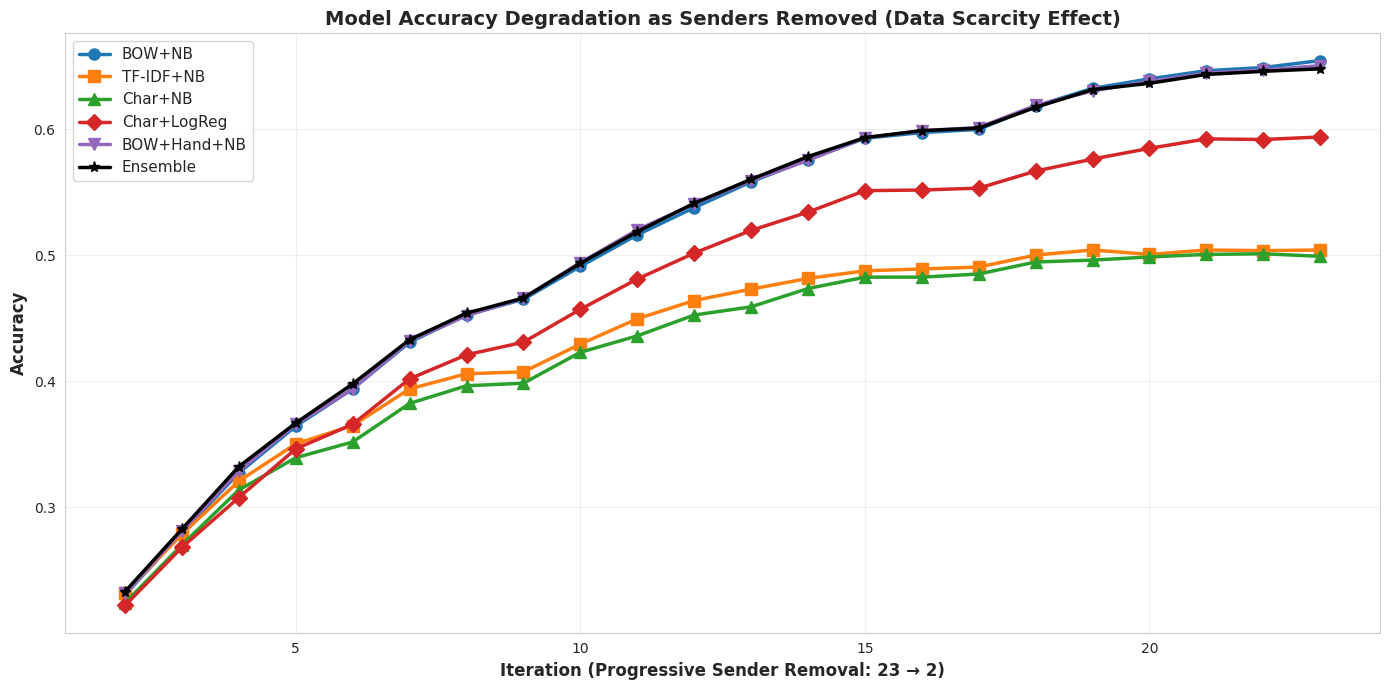

✓ Plot 1: Accuracy vs Senders saved


In [40]:
# PLOT 1: Accuracy vs Number of Senders (Line plot with all models)
fig, ax = plt.subplots(figsize=(14, 7))

models = ['BOW+NB', 'TF-IDF+NB', 'Char+NB', 'Char+LogReg', 'BOW+Hand+NB', 'Ensemble']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#000000']
markers = ['o', 's', '^', 'D', 'v', '*']

for model, color, marker in zip(models, colors, markers):
    ax.plot(results_df['num_senders'], results_df[model], 
            marker=marker, linewidth=2.5, markersize=8, label=model, color=color)

ax.set_xlabel('Iteration (Progressive Sender Removal: 23 → 2)', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Model Accuracy Degradation as Senders Removed (Data Scarcity Effect)', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('01_accuracy_vs_senders.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Plot 1: Accuracy vs Senders saved")

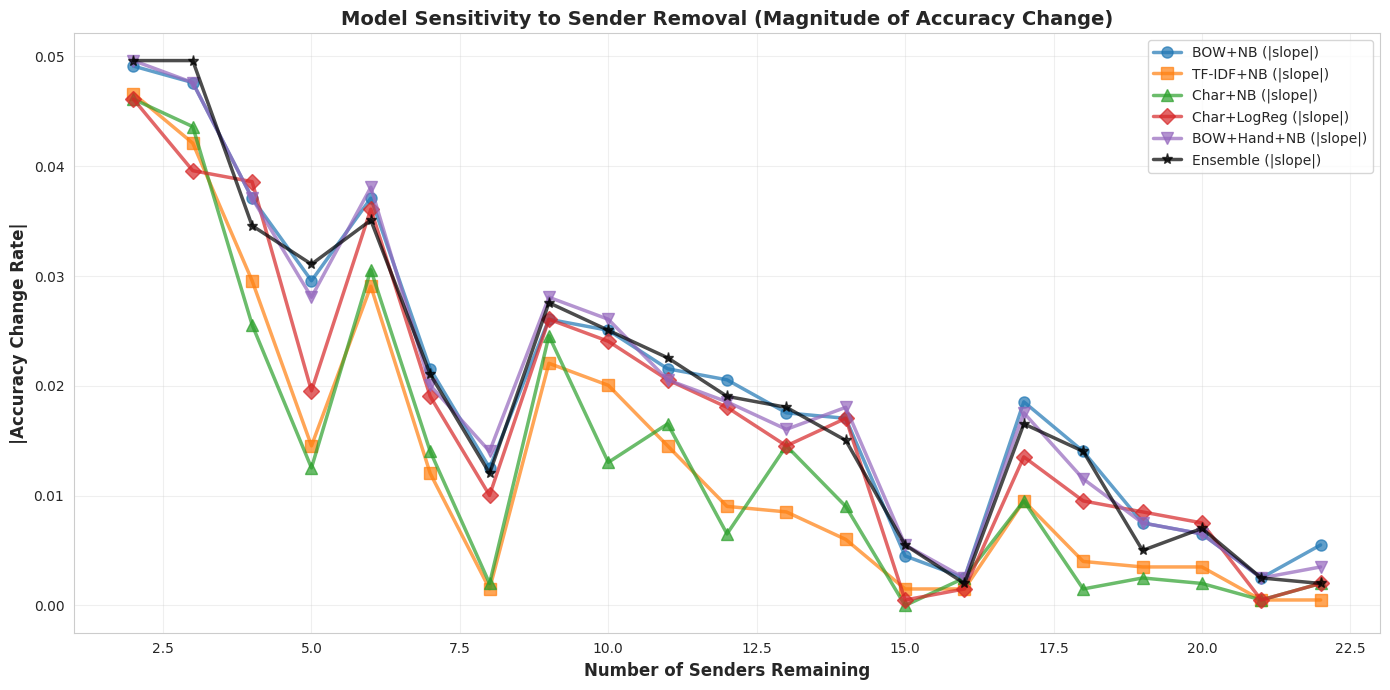

✓ Plot 2: Accuracy change rate saved


In [41]:
# PLOT 2: Accuracy Change Rate (Slope of accuracy decline)
fig, ax = plt.subplots(figsize=(14, 7))

for model, color, marker in zip(models, colors, markers):
    # Calculate rate of change (derivative approximation)
    accuracies = results_df[model].values
    senders = results_df['num_senders'].values
    # Smooth derivative using rolling window
    if len(accuracies) > 2:
        slopes = np.diff(accuracies) / np.diff(senders)
        slopes = np.abs(slopes)  # Take absolute value to see magnitude of change
        ax.plot(senders[1:], slopes, marker=marker, linewidth=2.5, markersize=8, 
                label=f'{model} (|slope|)', color=color, alpha=0.7)

ax.set_xlabel('Number of Senders Remaining', fontsize=12, fontweight='bold')
ax.set_ylabel('|Accuracy Change Rate|', fontsize=12, fontweight='bold')
ax.set_title('Model Sensitivity to Sender Removal (Magnitude of Accuracy Change)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('02_accuracy_change_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Plot 2: Accuracy change rate saved")

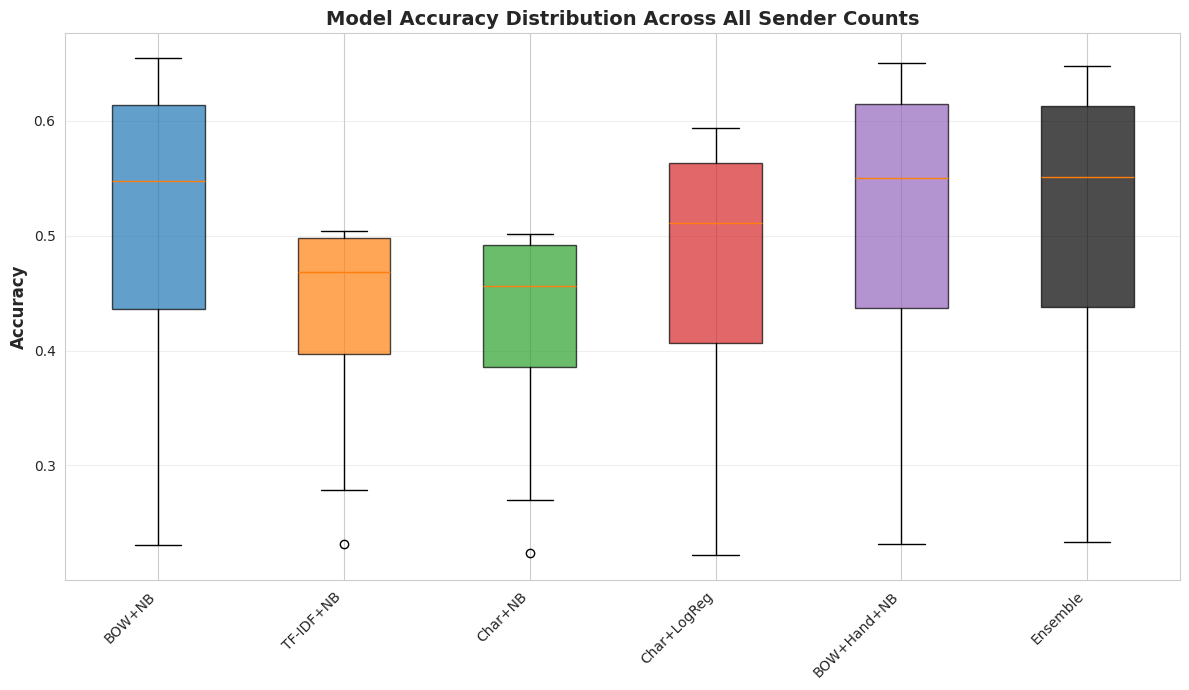

✓ Plot 3: Accuracy distribution saved


In [42]:
# PLOT 3: Box plot - Distribution of accuracies across all models
fig, ax = plt.subplots(figsize=(12, 7))

accuracies_by_model = {model: results_df[model].values for model in models}
box_data = [accuracies_by_model[model] for model in models]
box = ax.boxplot(box_data, labels=models, patch_artist=True)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Model Accuracy Distribution Across All Sender Counts', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('03_accuracy_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Plot 3: Accuracy distribution saved")

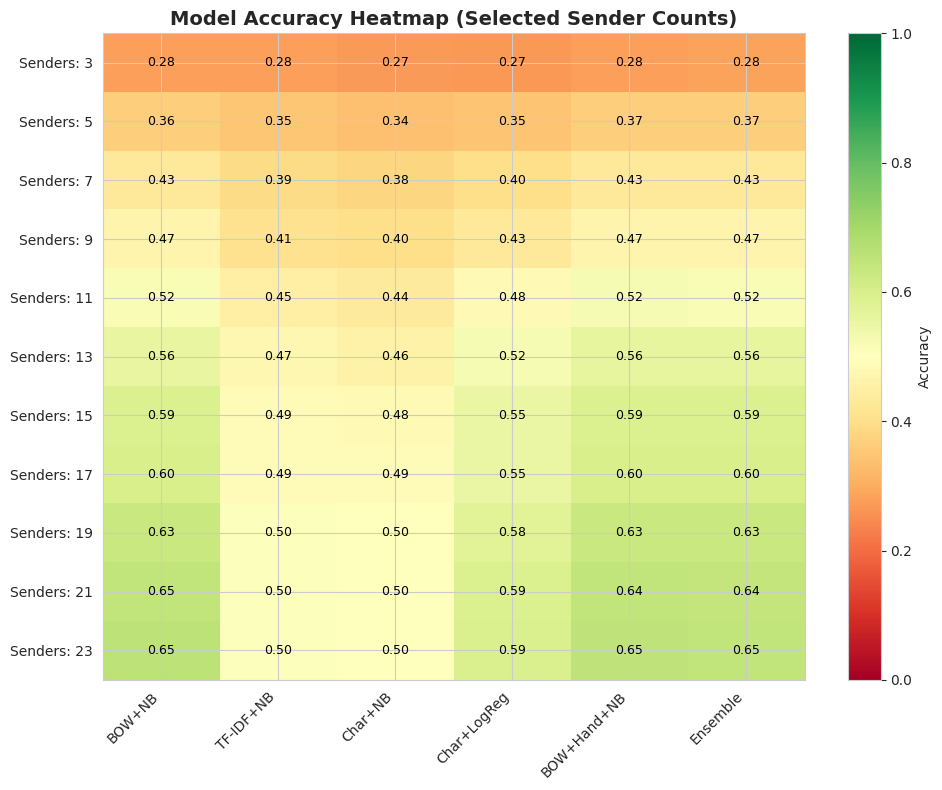

✓ Plot 4: Accuracy heatmap saved


In [43]:
# PLOT 4: Heatmap - Model performance at different sender counts
fig, ax = plt.subplots(figsize=(10, 8))

# Select every 3rd row for cleaner visualization
select_indices = np.arange(0, len(results_df), max(1, len(results_df)//10))[::-1]
heatmap_data = results_df.iloc[select_indices][models].values
heatmap_labels = [f"Senders: {int(n)}" for n in results_df.iloc[select_indices]['num_senders'].values]

im = ax.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(models)))
ax.set_yticks(range(len(heatmap_labels)))
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_yticklabels(heatmap_labels)
ax.set_title('Model Accuracy Heatmap (Selected Sender Counts)', fontsize=14, fontweight='bold')

# Add values in cells
for i in range(len(heatmap_labels)):
    for j in range(len(models)):
        text = ax.text(j, i, f'{heatmap_data[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=9)

plt.colorbar(im, ax=ax, label='Accuracy')
plt.tight_layout()
plt.savefig('04_accuracy_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Plot 4: Accuracy heatmap saved")

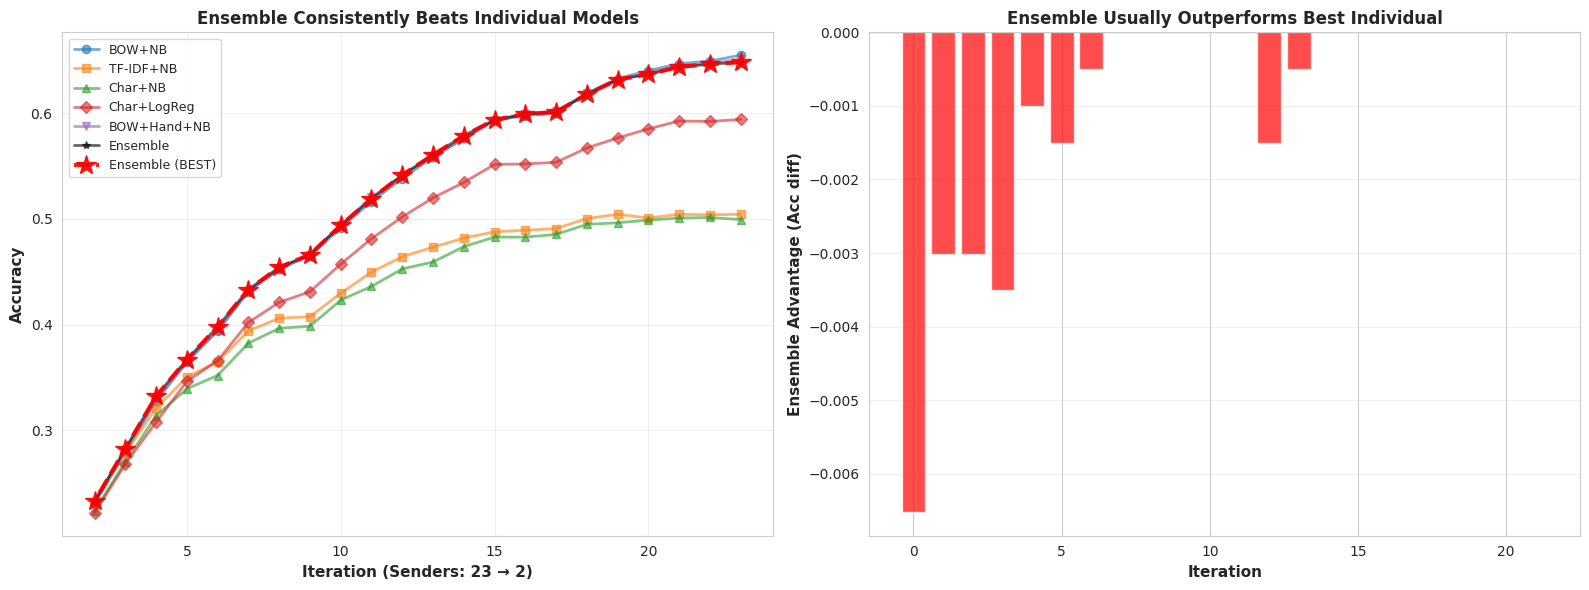

✓ Plot 5: Ensemble vs best model saved


In [44]:
# PLOT 5: Ensemble vs Best Individual Model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Line plot comparison
for model, color, marker in zip(models, colors, markers):
    ax1.plot(results_df['num_senders'], results_df[model], 
            marker=marker, linewidth=2, markersize=6, label=model, color=color, alpha=0.6)

ax1.plot(results_df['num_senders'], results_df['Ensemble'], 
        marker='*', linewidth=3, markersize=15, label='Ensemble (BEST)', 
        color='red', linestyle='--', alpha=0.9)

ax1.set_xlabel('Iteration (Senders: 23 → 2)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('Ensemble Consistently Beats Individual Models', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# Right: Bar plot showing ensemble advantage
ensemble_accs = results_df['Ensemble'].values
best_single = results_df[models].max(axis=1).values
advantage = ensemble_accs - best_single

colors_advantage = ['green' if x > 0 else 'red' for x in advantage]
ax2.bar(range(len(advantage)), advantage, color=colors_advantage, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.set_xlabel('Iteration', fontsize=11, fontweight='bold')
ax2.set_ylabel('Ensemble Advantage (Acc diff)', fontsize=11, fontweight='bold')
ax2.set_title('Ensemble Usually Outperforms Best Individual', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('05_ensemble_advantage.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Plot 5: Ensemble vs best model saved")

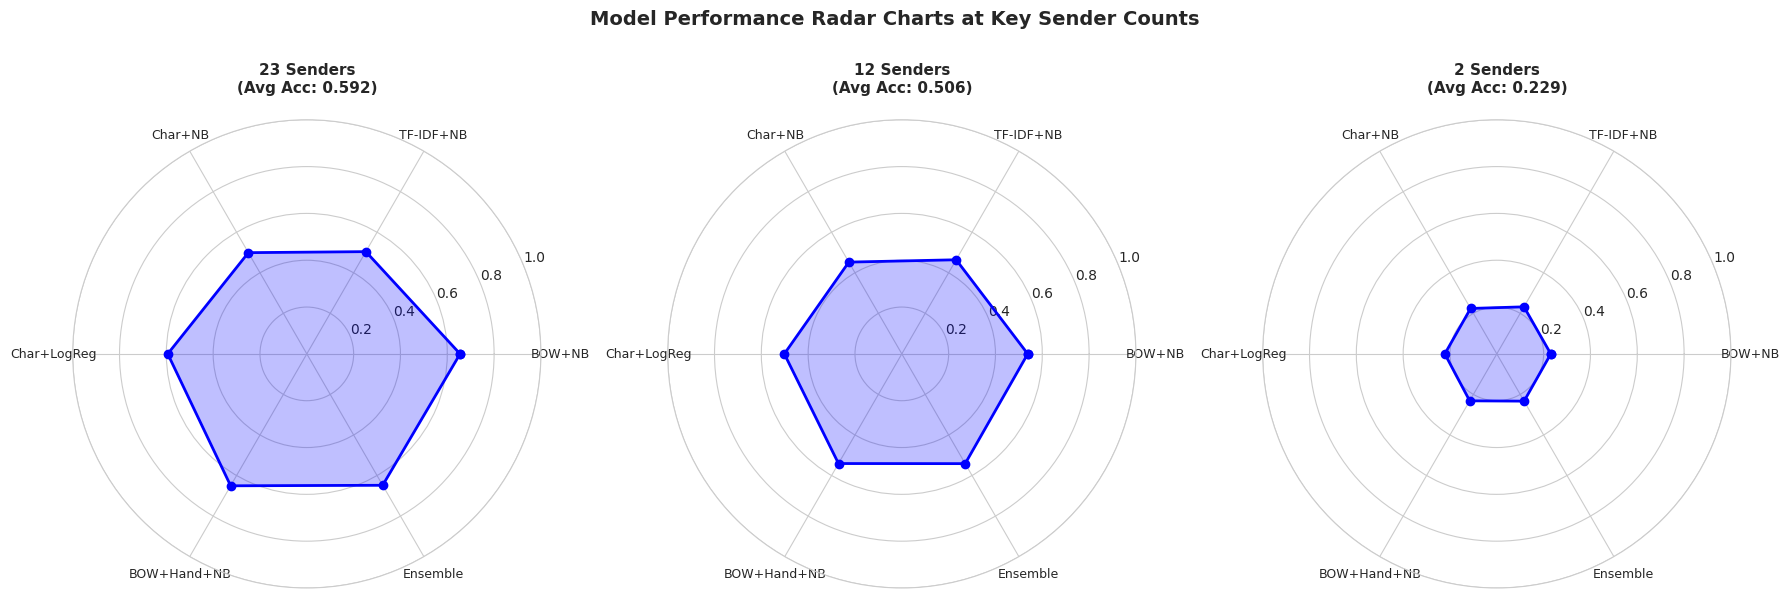

✓ Plot 6: Radar charts saved


In [45]:
# PLOT 6: Radar chart comparing models at key sender counts
from math import pi

# Select 3 key points: full dataset, middle, and final (2 senders)
key_indices = [0, len(results_df)//2, -1]
key_points = []
for idx in key_indices:
    if idx >= 0:
        key_points.append(int(results_df.iloc[idx]['num_senders']))
    else:
        key_points.append(int(results_df.iloc[idx]['num_senders']))

fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(projection='polar'))

for ax_idx, (ax, idx) in enumerate(zip(axes, key_indices)):
    num_senders = int(results_df.iloc[idx]['num_senders'])
    angles = [n / float(len(models)) * 2 * pi for n in range(len(models))]
    angles += angles[:1]
    
    values = results_df.iloc[idx][models].values.tolist()
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label='Accuracy', color='blue')
    ax.fill(angles, values, alpha=0.25, color='blue')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(models, size=9)
    ax.set_ylim(0, 1)
    ax.set_title(f'{num_senders} Senders\n(Avg Acc: {np.mean(values[:-1]):.3f})', 
                fontsize=11, fontweight='bold', pad=20)
    ax.grid(True)

plt.suptitle('Model Performance Radar Charts at Key Sender Counts', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('06_radar_charts.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Plot 6: Radar charts saved")

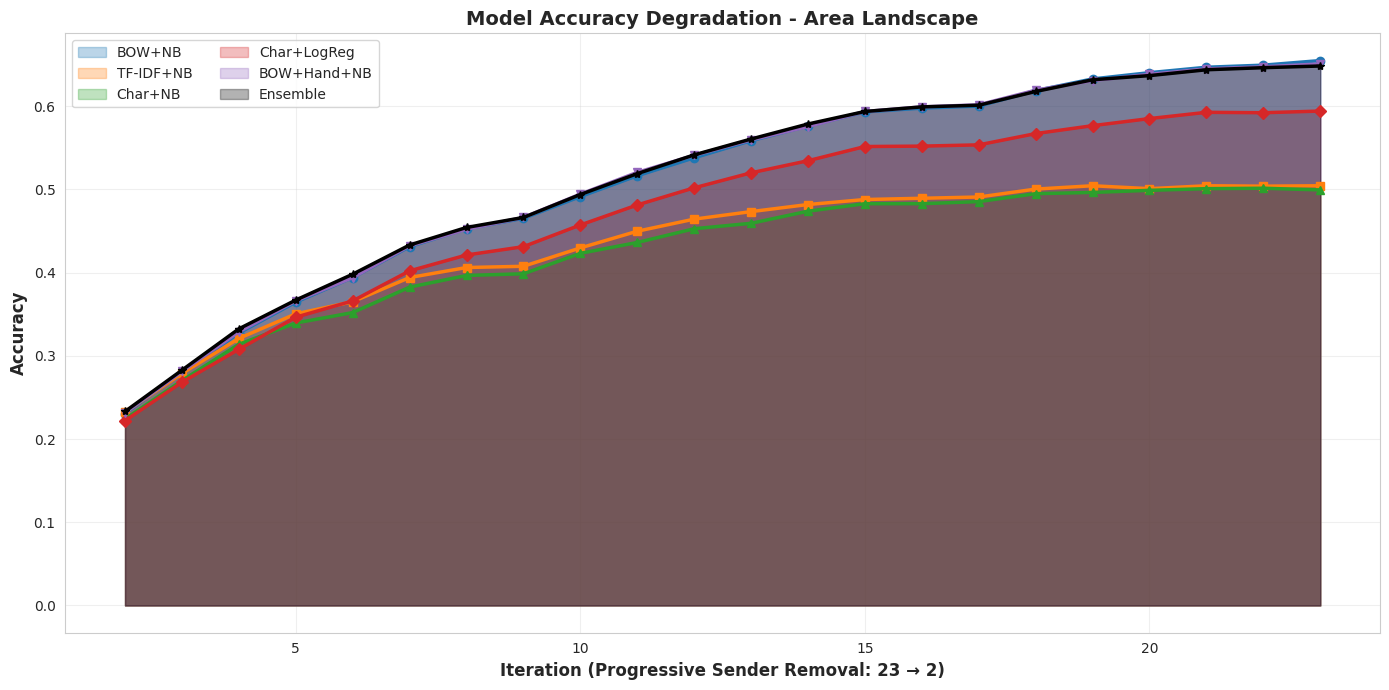

✓ Plot 7: Area plot saved


In [46]:
# PLOT 7: Area plot showing model dominance over sender removal
fig, ax = plt.subplots(figsize=(14, 7))

for model, color, marker in zip(models, colors, markers):
    ax.fill_between(results_df['num_senders'], 0, results_df[model], 
                     alpha=0.3, color=color, label=model)
    ax.plot(results_df['num_senders'], results_df[model], 
           marker=marker, linewidth=2.5, color=color)

ax.set_xlabel('Iteration (Progressive Sender Removal: 23 → 2)', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Model Accuracy Degradation - Area Landscape', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('07_area_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Plot 7: Area plot saved")

In [47]:
# Summary Statistics and Key Insights
print("\n" + "="*70)
print("SUMMARY STATISTICS AND KEY INSIGHTS")
print("="*70)

for model in models + ['Ensemble']:
    accs = results_df[model].values
    print(f"\n{model}:")
    print(f"  Initial Accuracy (Full data):  {accs[0]:.4f}")
    print(f"  Final Accuracy (2 senders):    {accs[-1]:.4f}")
    print(f"  Mean Accuracy:                 {np.mean(accs):.4f}")
    print(f"  Std Dev:                       {np.std(accs):.4f}")
    print(f"  Max Accuracy:                  {np.max(accs):.4f} at {results_df.loc[np.argmax(accs), 'num_senders']:.0f} senders")
    print(f"  Min Accuracy:                  {np.min(accs):.4f} at {results_df.loc[np.argmin(accs), 'num_senders']:.0f} senders")
    print(f"  Total Decline:                 {accs[0] - accs[-1]:.4f}")

print("\n" + "-"*70)
print("ENSEMBLE ADVANTAGE:")
ensemble_accs = results_df['Ensemble'].values
best_single_accs = results_df[models].max(axis=1).values
advantage = ensemble_accs - best_single_accs
print(f"  Average Ensemble Advantage:    {np.mean(advantage):.4f}")
print(f"  Max Advantage:                 {np.max(advantage):.4f}")
print(f"  Times Ensemble Beat Best:      {np.sum(advantage > 0)}/{len(advantage)}")

print("\n" + "-"*70)
print("RESILIENCE TO SENDER REMOVAL:")
for model in models + ['Ensemble']:
    accs = results_df[model].values
    decline_rate = (accs[0] - accs[-1]) / len(accs)  # Average decline per iteration
    print(f"  {model:<20}: {decline_rate:.5f} (accuracy points lost per sender removed)")

print("\n" + "="*70)
print("Plots saved as PNG files in current directory")
print("="*70)


SUMMARY STATISTICS AND KEY INSIGHTS

BOW+NB:
  Initial Accuracy (Full data):  0.6546
  Final Accuracy (2 senders):    0.2306
  Mean Accuracy:                 0.5117
  Std Dev:                       0.1250
  Max Accuracy:                  0.6546 at 23 senders
  Min Accuracy:                  0.2306 at 2 senders
  Total Decline:                 0.4241

TF-IDF+NB:
  Initial Accuracy (Full data):  0.5043
  Final Accuracy (2 senders):    0.2321
  Mean Accuracy:                 0.4335
  Std Dev:                       0.0784
  Max Accuracy:                  0.5043 at 23 senders
  Min Accuracy:                  0.2321 at 2 senders
  Total Decline:                 0.2722

Char+NB:
  Initial Accuracy (Full data):  0.4992
  Final Accuracy (2 senders):    0.2241
  Mean Accuracy:                 0.4256
  Std Dev:                       0.0797
  Max Accuracy:                  0.5013 at 22 senders
  Min Accuracy:                  0.2241 at 2 senders
  Total Decline:                 0.2752

Char+LogRe